In [1]:
import sys
import optuna
import pandas as pd
from dotenv import load_dotenv
from strategies_utils import analyze_strategies, get_best_leagues, get_best_strategies

In [2]:
import os
os.chdir("../models/")
from feature_engineering import get_mask, round_to_step, get_return, add_week_column
from etl_pipeline_local import get_over_15_table, get_win_1x_table, get_btts_table, get_over_25_table, get_goal_home_ht_table
os.chdir("../strategies/")
load_dotenv()

True

In [3]:
strategy_dict = dict()

# 1. Over 1.5

In [4]:
target_col = "over_15"

STUDY_NAME = f"{target_col}_aggregated_study"

study = optuna.load_study(
    study_name=STUDY_NAME,
    storage="sqlite:///../../data/output/optuna_model/aggregated_study.db",
)

print("Totale trial salvati:", len(study.trials))
print("Best assoluto:", study.best_trial.value, study.best_trial.params)

top_trials = sorted(study.trials, key=lambda t: -t.value)

Totale trial salvati: 3
Best assoluto: -0.13275429337616318 {'underOver_quote_diffRealCurrU_use_min': False, 'underOver_quote_diffRealCurrU_use_max': True, 'use_underOver_quote_diffRealCurrU': False, 'underOver_quote_diffRealCurrU_min': 85, 'underOver_quote_diffRealCurrU_max': 300, 'goalNoGoal_stats_avgGoalTakenAway_use_min': True, 'goalNoGoal_stats_avgGoalTakenAway_use_max': False, 'use_goalNoGoal_stats_avgGoalTakenAway': True, 'goalNoGoal_stats_avgGoalTakenAway_min': 1.4000000000000001, 'goalNoGoal_stats_avgGoalTakenAway_max': 4.2, 'goalNoGoal_flashback_m24_include_missing': False, 'goalNoGoal_flashback_m24_use_min': True, 'goalNoGoal_flashback_m24_use_max': True, 'use_goalNoGoal_flashback_m24': True, 'goalNoGoal_flashback_m24_min': 62, 'goalNoGoal_flashback_m24_max': 63, 'underOver_chance_over25_use_min': False, 'underOver_chance_over25_use_max': True, 'use_underOver_chance_over25': True, 'underOver_chance_over25_min': 25, 'underOver_chance_over25_max': 60, 'underOver_comparison_aff

/tmp/ipykernel_2063/141665692.py:10: UserWarning: The distribution is specified by [1.2000000000000002, 6.2] and step=0.2, but the range is not divisible by `step`. It will be replaced with [1.2000000000000002, 6.0].
  print("Totale trial salvati:", len(study.trials))
/tmp/ipykernel_2063/141665692.py:10: UserWarning: The distribution is specified by [1.2000000000000002, 6.6000000000000005] and step=0.2, but the range is not divisible by `step`. It will be replaced with [1.2000000000000002, 6.6000000000000005].
  print("Totale trial salvati:", len(study.trials))


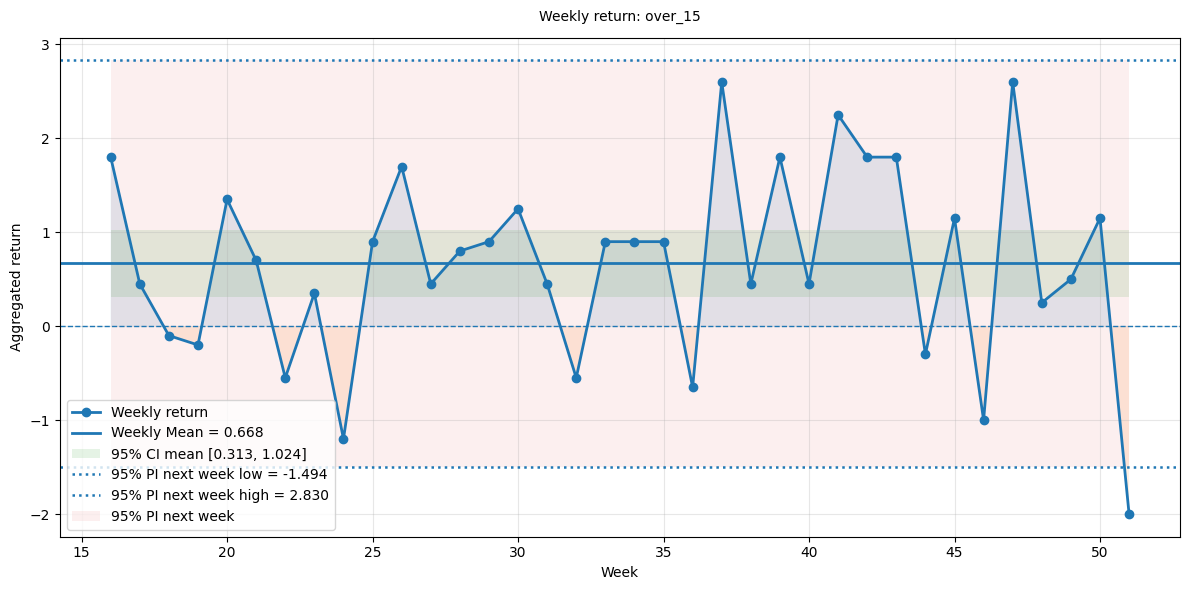

In [ ]:
# Choose best trial
best_trial = top_trials[0]
feature_bins_map = best_trial.user_attrs["feature_bins_map"]
params_dict = best_trial.user_attrs["params_dict"]
# Bet setup
target_col = "over_15"
odds_col: str = "over_15_odds"

# Load data
df_loaded = get_over_15_table()
df_loaded = df_loaded.sort_values('time').reset_index(drop=True)
df = df_loaded.copy()

# Feature Engineering
df[odds_col] = 1.45
df["return"] = df.apply(lambda x: get_return(strategy=x[target_col], odds=x[odds_col]), axis=1).copy()
df["week"] = add_week_column(df)
df = df[df["underOver_quote_currentU"] <= 1.7]
df["strategy"] = target_col

# Create the test binned dataframe
df_binned = df.copy()

for feat, step in feature_bins_map.items():
    df_binned[feat] = [round_to_step(x, step) for x in df_binned[feat]]

    if isinstance(step, int):
        df_binned[feat] = df_binned[feat].astype("Int64")

df_binned = df_binned.sort_values(by="time", ascending=False)

mask = get_mask(df_binned, best_trial.user_attrs["params_dict"])

df_filtered = df_binned[mask]

real_quote = 1. / (df_filtered[target_col].sum() / df_filtered.shape[0])

strategy_dict[target_col] = {"df_filtered": df_filtered, "real_quote": real_quote, "settings": {"feature_bins_map": feature_bins_map, "params_dict": params_dict}}
weekly_return, stats = analyze_strategies(df_filtered[['return', 'week', 'strategy']], strategies=[target_col], print_pi=True)

In [6]:
get_best_strategies(df_filtered.rename(columns={target_col: "result", "time": "date"}))

,weekly_mean_return,weekly_std_return,weekly_counts,weekly_std_counts,total_counts,accuracy
over_15,0.67,1.05,3.20,3.35,163,0.80


# 2. DNB 1

In [7]:
target_col = "dnb_1"

STUDY_NAME = f"{target_col}_aggregated_study"

study = optuna.load_study(
    study_name=STUDY_NAME,
    storage="sqlite:///../../data/output/optuna_model/aggregated_study.db",
)

print("Totale trial salvati:", len(study.trials))
print("Best assoluto:", study.best_trial.value, study.best_trial.params)

top_trials = sorted(study.trials, key=lambda t: -t.value)

Totale trial salvati: 1
Best assoluto: -0.4140076147684093 {'underOver_comparison_affini_use_min': False, 'underOver_comparison_affini_use_max': True, 'use_underOver_comparison_affini': False, 'underOver_comparison_affini_min': 500, 'underOver_comparison_affini_max': 1000, 'underOver_quote_diffRealCurrO_use_min': False, 'underOver_quote_diffRealCurrO_use_max': True, 'use_underOver_quote_diffRealCurrO': True, 'underOver_quote_diffRealCurrO_min': 55, 'underOver_quote_diffRealCurrO_max': 190, 'underOver_quote_realU_use_min': True, 'underOver_quote_realU_use_max': True, 'use_underOver_quote_realU': False, 'underOver_quote_realU_min': 2.0, 'underOver_quote_realU_max': 5.800000000000001, 'evaluation_valUnderOver_cat_idx': 47, 'use_evaluation_valUnderOver': True, 'underOver_quote_diffInitialCurrO_use_min': False, 'underOver_quote_diffInitialCurrO_use_max': True, 'use_underOver_quote_diffInitialCurrO': True, 'underOver_quote_diffInitialCurrO_min': -15, 'underOver_quote_diffInitialCurrO_max': 5

/tmp/ipykernel_2063/985784607.py:10: UserWarning: The distribution is specified by [1.2000000000000002, 6.2] and step=0.2, but the range is not divisible by `step`. It will be replaced with [1.2000000000000002, 6.0].
  print("Totale trial salvati:", len(study.trials))
/tmp/ipykernel_2063/985784607.py:10: UserWarning: The distribution is specified by [1.2000000000000002, 6.6000000000000005] and step=0.2, but the range is not divisible by `step`. It will be replaced with [1.2000000000000002, 6.6000000000000005].
  print("Totale trial salvati:", len(study.trials))
/tmp/ipykernel_2063/985784607.py:10: UserWarning: The distribution is specified by [1.2000000000000002, 3.8000000000000003] and step=0.2, but the range is not divisible by `step`. It will be replaced with [1.2000000000000002, 3.8000000000000003].
  print("Totale trial salvati:", len(study.trials))
/tmp/ipykernel_2063/985784607.py:10: UserWarning: The distribution is specified by [1.2000000000000002, 4.0] and step=0.2, but the ra

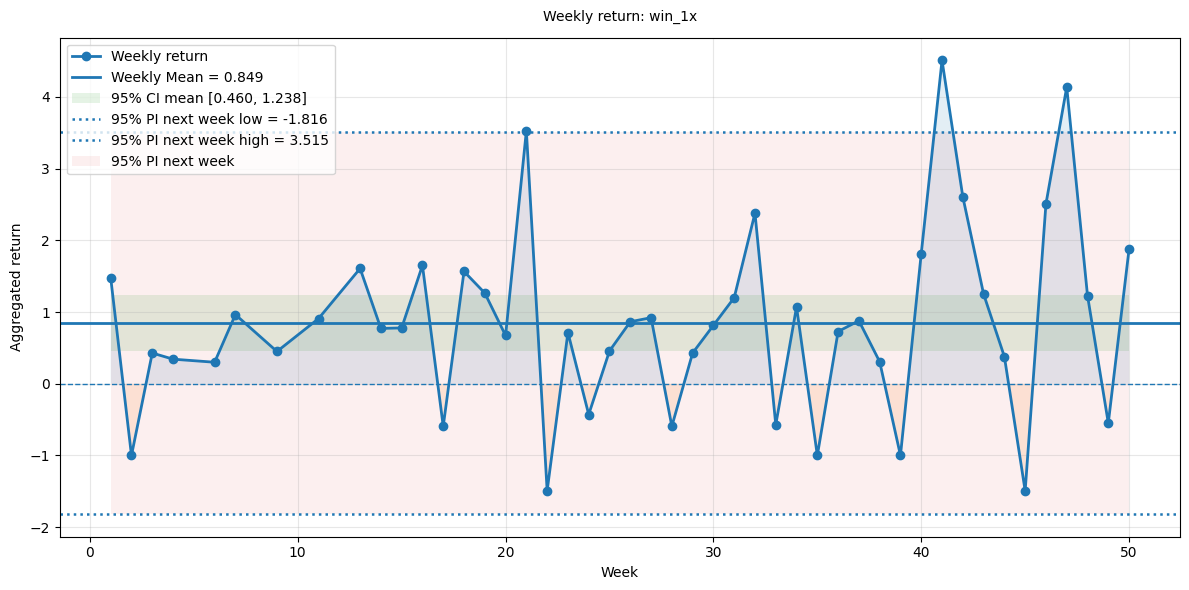

In [ ]:
# Choose best trial
best_trial = top_trials[0]
feature_bins_map = best_trial.user_attrs["feature_bins_map"]
params_dict = best_trial.user_attrs["params_dict"]

# Bet setup
target_col = "win_1x"
odds_col: str = "dnb_1_odds"

# Load data
df_loaded = get_win_1x_table()
df_loaded = df_loaded.sort_values('time').reset_index(drop=True)
df = df_loaded.copy()

# Feature Engineering
def scale_odd(quota_orig):
    return (3/7) * quota_orig + 0.4857142857

df[odds_col] = [scale_odd(x) for x in df['chance1x2_quote_current1']]
df["return"] = df.apply(lambda x: get_return(strategy=x[target_col], odds=x[odds_col]), axis=1).copy()
df["week"] = add_week_column(df)
df = df[(df["chance1x2_quote_current1"] >= 1.9) & (df["chance1x2_quote_current1"] <= 2.6)]

df["strategy"] = target_col

# Create the test binned dataframe
df_binned = df.copy()

for feat, step in feature_bins_map.items():
    df_binned[feat] = [round_to_step(x, step) for x in df_binned[feat]]

    if isinstance(step, int):
        df_binned[feat] = df_binned[feat].astype("Int64")

df_binned = df_binned.sort_values(by="time", ascending=False)

mask = get_mask(df_binned, best_trial.user_attrs["params_dict"])

df_filtered = df_binned[mask]
real_quote = 1. / (df_filtered[target_col].sum() / df_filtered.shape[0])

weekly_return, stats = analyze_strategies(df_filtered, strategies=[target_col], print_pi=True)
strategy_dict[target_col] = {"df_filtered": df_filtered, "real_quote": real_quote, "settings": {"feature_bins_map": feature_bins_map, "params_dict": params_dict}}

In [9]:
get_best_strategies(df_filtered.rename(columns={target_col: "result", "time": "date"}))

,weekly_mean_return,weekly_std_return,weekly_counts,weekly_std_counts,total_counts,accuracy
win_1x,0.85,1.31,4.58,3.77,229,0.81


# 3. BTTS

In [10]:
target_col = "btts"

STUDY_NAME = f"{target_col}_aggregated_study"

study = optuna.load_study(
    study_name=STUDY_NAME,
    storage="sqlite:///../../data/output/optuna_model/aggregated_study.db",
)

print("Totale trial salvati:", len(study.trials))
print("Best assoluto:", study.best_trial.value, study.best_trial.params)

top_trials = sorted(study.trials, key=lambda t: -t.value)

Totale trial salvati: 1
Best assoluto: -0.28668743594845136 {'goalNoGoal_quote_diffRealCurrNG_use_min': False, 'goalNoGoal_quote_diffRealCurrNG_use_max': True, 'use_goalNoGoal_quote_diffRealCurrNG': False, 'goalNoGoal_quote_diffRealCurrNG_min': -45, 'goalNoGoal_quote_diffRealCurrNG_max': 125, 'underOver_chance_over45_use_min': True, 'underOver_chance_over45_use_max': True, 'use_underOver_chance_over45': True, 'underOver_chance_over45_min': 35, 'underOver_chance_over45_max': 55, 'goalNoGoal_stats_avgGoalTakenAway_use_min': True, 'goalNoGoal_stats_avgGoalTakenAway_use_max': True, 'use_goalNoGoal_stats_avgGoalTakenAway': True, 'goalNoGoal_stats_avgGoalTakenAway_min': 1.8, 'goalNoGoal_stats_avgGoalTakenAway_max': 3.2, 'underOver_quote_initialU_use_min': True, 'underOver_quote_initialU_use_max': False, 'use_underOver_quote_initialU': True, 'underOver_quote_initialU_min': 2.0, 'underOver_quote_initialU_max': 3.6000000000000005}


/tmp/ipykernel_2063/4038310933.py:10: UserWarning: The distribution is specified by [1.2000000000000002, 4.6000000000000005] and step=0.2, but the range is not divisible by `step`. It will be replaced with [1.2000000000000002, 4.6000000000000005].
  print("Totale trial salvati:", len(study.trials))
/tmp/ipykernel_2063/4038310933.py:10: UserWarning: The distribution is specified by [1.2000000000000002, 4.8] and step=0.2, but the range is not divisible by `step`. It will be replaced with [1.2000000000000002, 4.6000000000000005].
  print("Totale trial salvati:", len(study.trials))


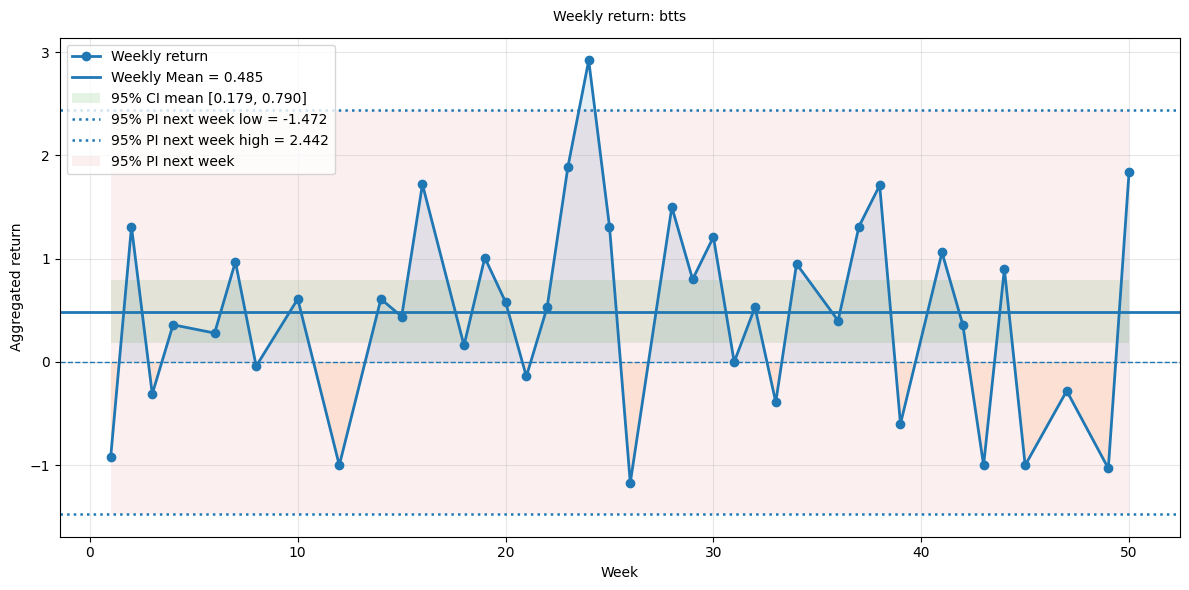

In [ ]:
# Choose best trial
best_trial = top_trials[0]
feature_bins_map = best_trial.user_attrs["feature_bins_map"]
params_dict = best_trial.user_attrs["params_dict"]

# Bet setup
target_col = "btts"
odds_col: str = "goalNoGoal_quote_currentGG"

# Load data
df_loaded = get_btts_table()
df_loaded = df_loaded.sort_values('time').reset_index(drop=True)
df = df_loaded.copy()

# Feature Engineering


# Feature Engineering
df["return"] = df.apply(lambda x: get_return(strategy=x[target_col], odds=x[odds_col]), axis=1).copy()
df["week"] = add_week_column(df)
df["strategy"] = target_col

# Create the test binned dataframe
df_binned = df.copy()

for feat, step in feature_bins_map.items():
    df_binned[feat] = [round_to_step(x, step) for x in df_binned[feat]]

    if isinstance(step, int):
        df_binned[feat] = df_binned[feat].astype("Int64")

df_binned = df_binned.sort_values(by="time", ascending=False)

mask = get_mask(df_binned, best_trial.user_attrs["params_dict"])

df_filtered = df_binned[mask]
real_quote = 1. / (df_filtered[target_col].sum() / df_filtered.shape[0])

weekly_return, stats = analyze_strategies(df_filtered, strategies=[target_col], print_pi=True)
strategy_dict[target_col] = {"df_filtered": df_filtered, "real_quote": real_quote, "settings": {"feature_bins_map": feature_bins_map, "params_dict": params_dict}}

In [12]:
get_best_strategies(df_filtered.rename(columns={target_col: "result", "time": "date"}))

,weekly_mean_return,weekly_std_return,weekly_counts,weekly_std_counts,total_counts,accuracy
btts,0.48,0.96,2.28,2.03,114,0.77


# 4. Over 2.5

In [13]:
target_col = "over_25"

STUDY_NAME = f"{target_col}_aggregated_study"

study = optuna.load_study(
    study_name=STUDY_NAME,
    storage="sqlite:///../../data/output/optuna_model/aggregated_study.db",
)

print("Totale trial salvati:", len(study.trials))
print("Best assoluto:", study.best_trial.value, study.best_trial.params)

top_trials = sorted(study.trials, key=lambda t: -t.value)

Totale trial salvati: 1
Best assoluto: -0.6398402202656642 {'goalNoGoal_stats_avgGoalTakenAway_use_min': True, 'goalNoGoal_stats_avgGoalTakenAway_use_max': True, 'use_goalNoGoal_stats_avgGoalTakenAway': True, 'goalNoGoal_stats_avgGoalTakenAway_min': 3.0, 'goalNoGoal_stats_avgGoalTakenAway_max': 3.2, 'goalNoGoal_multigoal_m24Away_use_min': True, 'goalNoGoal_multigoal_m24Away_use_max': True, 'use_goalNoGoal_multigoal_m24Away': False, 'goalNoGoal_multigoal_m24Away_min': 20, 'goalNoGoal_multigoal_m24Away_max': 45, 'goalNoGoal_quote_realNG_use_min': False, 'goalNoGoal_quote_realNG_use_max': True, 'use_goalNoGoal_quote_realNG': True, 'goalNoGoal_quote_realNG_min': 1.6, 'goalNoGoal_quote_realNG_max': 4.0}


/tmp/ipykernel_2063/2623453569.py:10: UserWarning: The distribution is specified by [1.2000000000000002, 6.6000000000000005] and step=0.2, but the range is not divisible by `step`. It will be replaced with [1.2000000000000002, 6.6000000000000005].
  print("Totale trial salvati:", len(study.trials))
/tmp/ipykernel_2063/2623453569.py:10: UserWarning: The distribution is specified by [1.2000000000000002, 6.8] and step=0.2, but the range is not divisible by `step`. It will be replaced with [1.2000000000000002, 6.6000000000000005].
  print("Totale trial salvati:", len(study.trials))


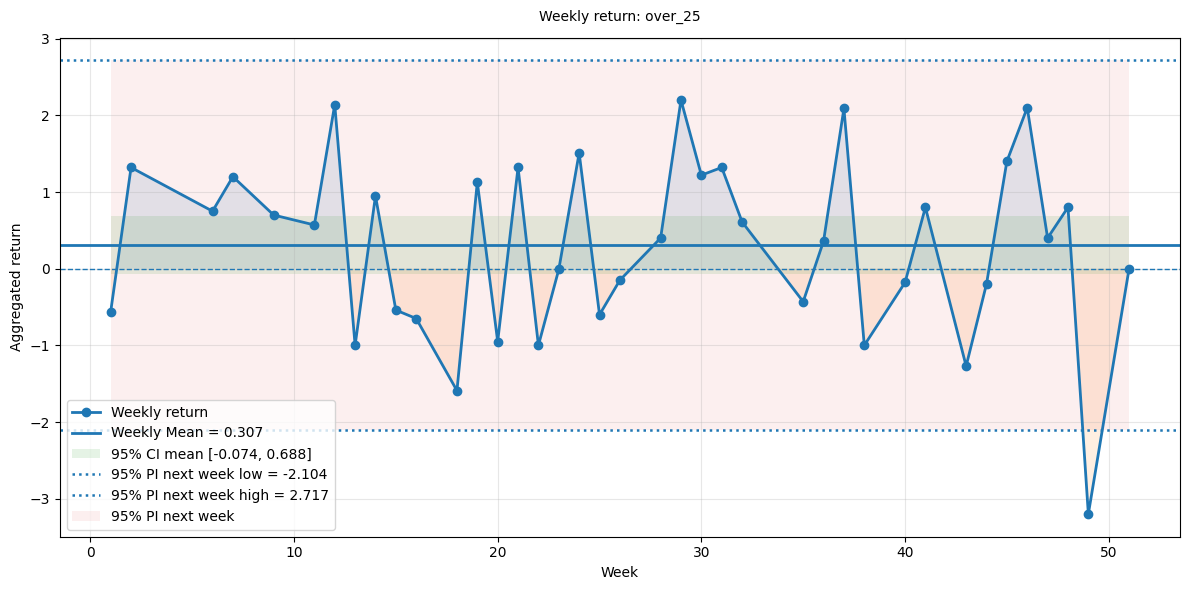

In [ ]:
# Choose best trial
best_trial = top_trials[0]
feature_bins_map = best_trial.user_attrs["feature_bins_map"]
params_dict = best_trial.user_attrs["params_dict"]

# Bet setup
target_col = "over_25"
odds_col: str = "underOver_quote_currentO"

# Load data
df_loaded = get_over_25_table()
df_loaded = df_loaded.sort_values('time').reset_index(drop=True)
df = df_loaded.copy()


# Feature Engineering
df["return"] = df.apply(lambda x: get_return(strategy=x[target_col], odds=x[odds_col]), axis=1).copy()
df["week"] = add_week_column(df)
df = df[df["underOver_quote_currentO"] >= 1.4]
df["strategy"] = target_col

# Create the test binned dataframe
df_binned = df.copy()

for feat, step in feature_bins_map.items():
    df_binned[feat] = [round_to_step(x, step) for x in df_binned[feat]]

    if isinstance(step, int):
        df_binned[feat] = df_binned[feat].astype("Int64")

df_binned = df_binned.sort_values(by="time", ascending=False)

mask = get_mask(df_binned, best_trial.user_attrs["params_dict"])

df_filtered = df_binned[mask]
real_quote = 1. / (df_filtered[target_col].sum() / df_filtered.shape[0])

weekly_return, stats = analyze_strategies(df_filtered, strategies=[target_col], print_pi=True)
strategy_dict[target_col] = {"df_filtered": df_filtered, "real_quote": real_quote, "settings": {"feature_bins_map": feature_bins_map, "params_dict": params_dict}}

In [15]:
get_best_strategies(df_filtered.rename(columns={target_col: "result", "time": "date"}))

,weekly_mean_return,weekly_std_return,weekly_counts,weekly_std_counts,total_counts,accuracy
over_25,0.31,1.18,2.55,3.06,130,0.68


# 5. Goal Home HT

In [26]:
target_col = "goal_home_ht"

STUDY_NAME = f"{target_col}_aggregated_study"

study = optuna.load_study(
    study_name=STUDY_NAME,
    storage="sqlite:///../../data/output/optuna_model/aggregated_study.db",
)

print("Totale trial salvati:", len(study.trials))
print("Best assoluto:", study.best_trial.value, study.best_trial.params)

top_trials = sorted(study.trials, key=lambda t: -t.value)

Totale trial salvati: 2
Best assoluto: -0.16990722582856632 {'chance1x2_flashback_pHt1_include_missing': False, 'chance1x2_flashback_pHt1_use_min': True, 'chance1x2_flashback_pHt1_use_max': True, 'use_chance1x2_flashback_pHt1': True, 'chance1x2_flashback_pHt1_min': 50, 'chance1x2_flashback_pHt1_max': 70, 'chance1x2_quote_diffInitialCurr2_include_missing': False, 'chance1x2_quote_diffInitialCurr2_use_min': False, 'chance1x2_quote_diffInitialCurr2_use_max': True, 'use_chance1x2_quote_diffInitialCurr2': True, 'chance1x2_quote_diffInitialCurr2_min': -15, 'chance1x2_quote_diffInitialCurr2_max': 0, 'chance1x2_flashback_p1_include_missing': True, 'chance1x2_flashback_p1_use_min': True, 'chance1x2_flashback_p1_use_max': False, 'use_chance1x2_flashback_p1': True, 'chance1x2_flashback_p1_min': 65, 'chance1x2_flashback_p1_max': 70, 'chance1x2_flashback_p2_include_missing': True, 'chance1x2_flashback_p2_use_min': True, 'chance1x2_flashback_p2_use_max': True, 'use_chance1x2_flashback_p2': False, 'c

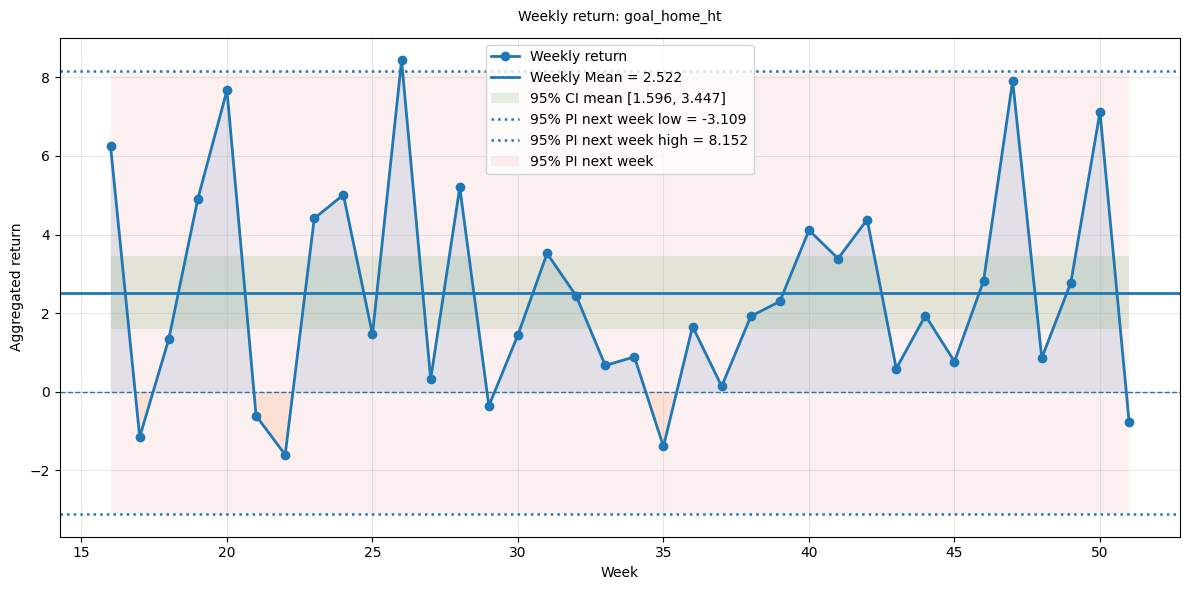

In [ ]:
# Choose best trial
best_trial = top_trials[1]
feature_bins_map = best_trial.user_attrs["feature_bins_map"]
params_dict = best_trial.user_attrs["params_dict"]

# Bet setup
target_col = "goal_home_ht"
odds_col: str = "underOver_quote_currentO"

# Load data
df_loaded = get_goal_home_ht_table()
df_loaded = df_loaded.sort_values('time').reset_index(drop=True)
df = df_loaded.copy()


# Feature Engineering
df["return"] = df.apply(lambda x: get_return(strategy=x[target_col], odds=x[odds_col]), axis=1).copy()
df["week"] = add_week_column(df)
df = df[df["underOver_quote_currentO"] >= 1.4]
df["strategy"] = target_col

# Create the test binned dataframe
df_binned = df.copy()

for feat, step in feature_bins_map.items():
    df_binned[feat] = [round_to_step(x, step) for x in df_binned[feat]]

    if isinstance(step, int):
        df_binned[feat] = df_binned[feat].astype("Int64")

df_binned = df_binned.sort_values(by="time", ascending=False)

mask = get_mask(df_binned, best_trial.user_attrs["params_dict"])

df_filtered = df_binned[mask]
real_quote = 1. / (df_filtered[target_col].sum() / df_filtered.shape[0])

weekly_return, stats = analyze_strategies(df_filtered, strategies=[target_col], print_pi=True)
strategy_dict[target_col] = {"df_filtered": df_filtered, "real_quote": real_quote, "settings": {"feature_bins_map": feature_bins_map, "params_dict": params_dict}}

In [18]:
get_best_strategies(df_filtered.rename(columns={target_col: "result", "time": "date"}))

,weekly_mean_return,weekly_std_return,weekly_counts,weekly_std_counts,total_counts,accuracy
goal_home_ht,2.52,2.74,11.49,9.90,586,0.67


# Forecast

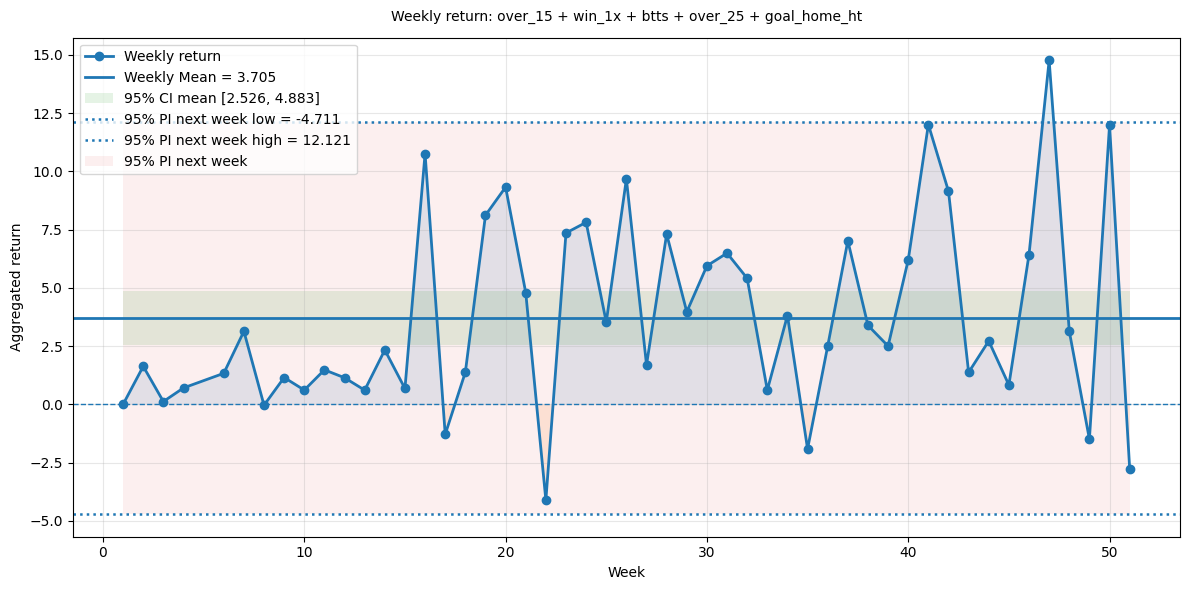

In [19]:
for i, key in enumerate(strategy_dict.keys()):
    if i == 0:
        df_final = strategy_dict[key]['df_filtered']
    else:
        df_item = strategy_dict[key]['df_filtered']
        df_final = pd.concat([df_final, df_item], axis=0)

df_final = df_final.reset_index(drop=True)

weekly_return, stats = analyze_strategies(df_final, strategies=strategy_dict.keys(), print_pi=True)

In [20]:
df_final = df_final.rename(columns={"team_league": "league"})

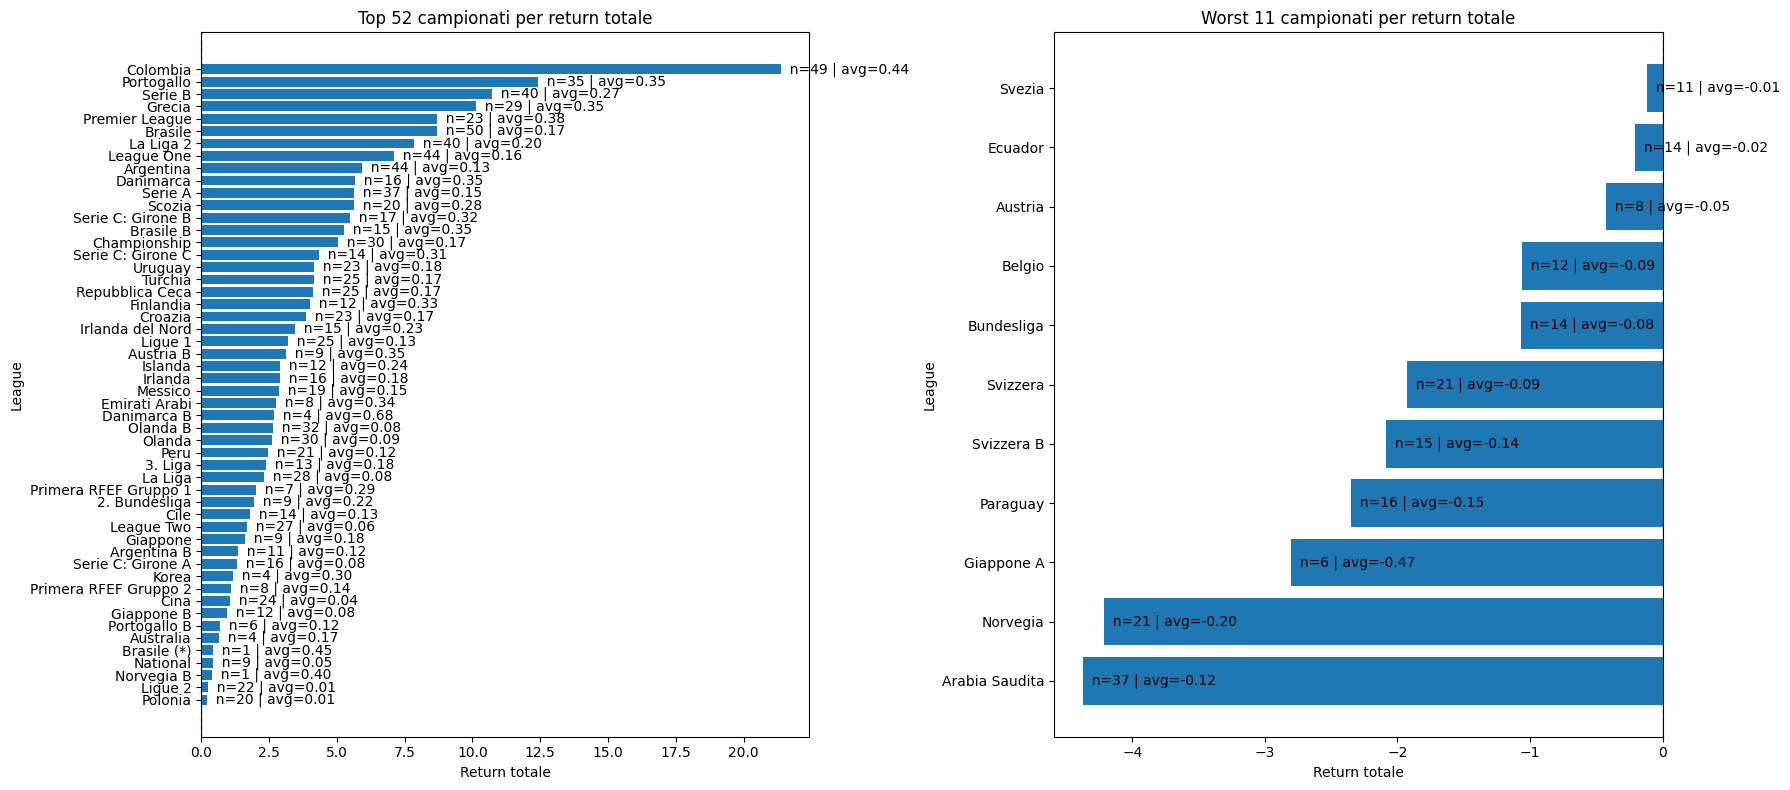

In [21]:
top_leagues = get_best_leagues(df_final, strategies=strategy_dict.keys())

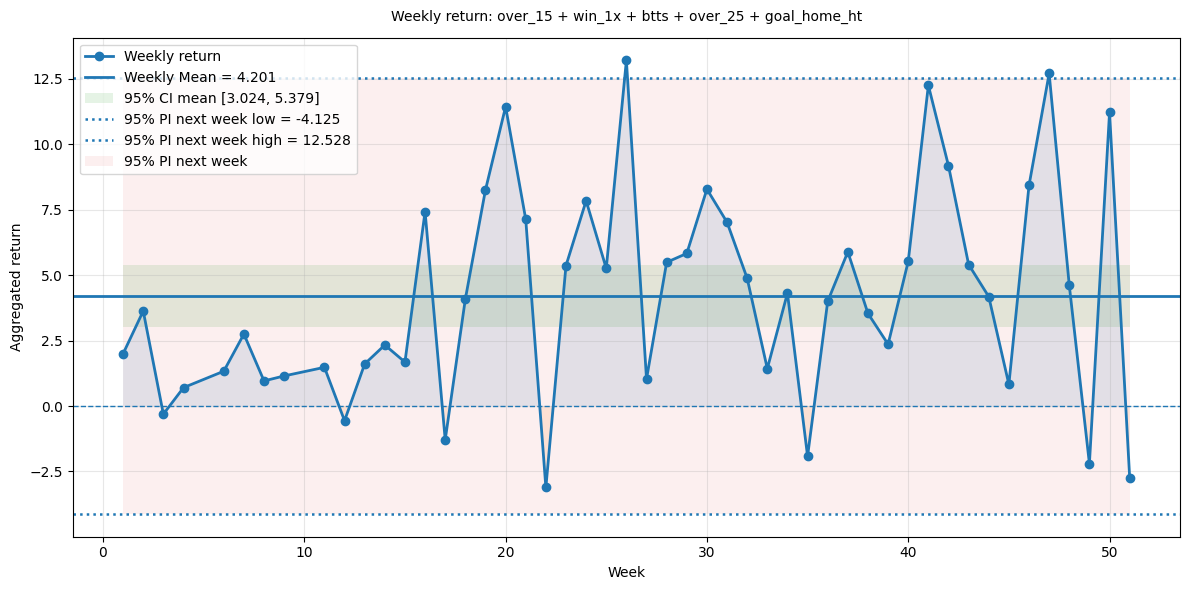

In [22]:
weekly_return, stats = analyze_strategies(df_final, strategies=strategy_dict.keys(), leagues=top_leagues.index.to_list(),print_pi=True)

In [25]:
df_final

,time,chance1x2_chance_p1,chance1x2_chance_px,chance1x2_chance_p2,chance1x2_chance_p1x,chance1x2_chance_p2x,chance1x2_chance_p12,chance1x2_chance_pHt1,chance1x2_chance_pHtx,chance1x2_chance_pHt2,...,over_15,over_15_odds,return,week,strategy,win_1x,dnb_1_odds,btts,over_25,goal_home_ht
0,2026-04-30 19:30:00,48.50,28.30,23.20,76.80,51.50,71.70,35.80,42.60,21.60,...,False,1.45,-1.00,51,over_15,<NA>,NaN,<NA>,<NA>,<NA>
1,2026-04-28 02:00:00,33.60,30.30,36.10,63.90,66.40,69.70,25.30,44.60,30.10,...,False,1.45,-1.00,51,over_15,<NA>,NaN,<NA>,<NA>,<NA>
2,2026-04-26 21:00:00,42.60,32.10,25.30,74.70,57.40,67.90,30.90,43.30,25.80,...,False,1.45,-1.00,50,over_15,<NA>,NaN,<NA>,<NA>,<NA>
3,2026-04-26 20:00:00,42.20,32.60,25.20,74.80,57.80,67.40,31.50,49.50,19.00,...,True,1.45,0.45,50,over_15,<NA>,NaN,<NA>,<NA>,<NA>
4,2026-04-26 18:30:00,28.20,35.60,36.20,63.80,71.80,64.40,19.90,55.00,25.10,...,False,1.45,-1.00,50,over_15,<NA>,NaN,<NA>,<NA>,<NA>
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1217,2025-08-31 14:00:00,68.90,19.30,11.80,88.20,31.10,80.70,49.50,40.60,9.90,...,<NA>,NaN,0.57,16,goal_home_ht,<NA>,NaN,<NA>,<NA>,True
1218,2025-08-30 17:00:00,76.00,16.40,7.60,92.40,24.00,83.60,66.40,25.00,8.60,...,<NA>,NaN,0.57,16,goal_home_ht,<NA>,NaN,<NA>,<NA>,True
1219,2025-08-30 13:35:00,47.90,26.40,25.70,74.30,52.10,73.60,34.30,38.80,26.90,...,<NA>,NaN,0.53,16,goal_home_ht,<NA>,NaN,<NA>,<NA>,True
1220,2025-08-30 13:30:00,67.10,19.60,13.30,86.70,32.90,80.40,48.50,34.20,17.30,...,<NA>,NaN,0.75,16,goal_home_ht,<NA>,NaN,<NA>,<NA>,True


In [23]:
output_dict = dict()

# output_dict["over_15"]= strategy_dict["over_15"]['settings']
# output_dict["dnb_1"]= strategy_dict["win_1x"]['settings']
output_dict["btts"]= strategy_dict["btts"]['settings']
output_dict["over_25"]= strategy_dict["over_25"]['settings']
# output_dict["goal_home_ht"] = strategy_dict["goal_home_ht"]['settings']
output_dict["top_leagues"] = top_leagues.index.to_list()

In [15]:
import json 
with open("strategies.json", "w", encoding="utf-8") as f:
    json.dump(output_dict, f, indent=2)